In [1]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3

TRAIN_DIR = r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\LWDCD\dataset_split\train"
VAL_DIR = r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\LWDCD\dataset_split\val"
TEST_DIR = r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\LWDCD\dataset_split\test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2351 images belonging to 3 classes.
Found 506 images belonging to 3 classes.
Found 505 images belonging to 3 classes.


In [3]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 456,899 (1.74 MB)

 Trainable params: 455,939 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [4]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "CustomCNN_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [5]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)

C:\Users\KristianHaltenJensen\anaconda4\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5098 - loss: 1.1747
Epoch 1: val_accuracy improved from -inf to 0.29644, saving model to CustomCNN_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.5105 - loss: 1.1729 - val_accuracy: 0.2964 - val_loss: 1.1773 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6296 - loss: 0.8619
Epoch 2: val_accuracy improved from 0.29644 to 0.35771, saving model to CustomCNN_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.6300 - loss: 0.8612 - val_accuracy: 0.3577 - val_loss: 1.9756 - learning_rate: 0.0010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7118 - loss: 0.7019
Epoch 3: val_accuracy improved from 0.35771 to 0.36364, saving model to CustomCNN_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.7118 - loss: 0.7020 - val_accuracy: 0.3636 - val_loss: 2.2358 - learning_rate: 0.0010
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accu

In [10]:
base_model.trainable = True

for layer in base_model.layers[:249]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8770 - loss: 0.3067
Epoch 1: val_accuracy did not improve from 0.94071
74/74 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.8769 - loss: 0.3069 - val_accuracy: 0.9289 - val_loss: 0.1837 - learning_rate: 1.0000e-05
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8921 - loss: 0.2703
Epoch 2: val_accuracy did not improve from 0.94071
74/74 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.8921 - loss: 0.2703 - val_accuracy: 0.9229 - val_loss: 0.1971 - learning_rate: 1.0000e-05
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8928 - loss: 0.2794
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 3: val_accuracy did not improve from 0.94071
74/74 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.8927 - loss: 0.2795 - val_accuracy: 0.9190 - val_loss: 0.2037 - learning_rate: 1.0000e-05
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9030 - loss: 0.2371
Epoch

In [7]:
history_dict = {
    key: [float(x) for x in values]
    for key, values in history.history.items()
}

with open("WheatNetwork_history_LWDCD.json", "w") as f:
    json.dump(history_dict, f, indent=4)

In [8]:
model.save("CustomCNN_final_LWDCD.keras")

In [9]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.8969 - loss: 0.2859
Test accuracy: 0.8515


In [10]:
pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 919ms/step
                  precision    recall  f1-score   support

   Healthy Wheat       0.79      0.93      0.85       175
       Leaf Rust       0.93      0.86      0.89       190
Wheat Loose Smut       0.84      0.75      0.79       140

        accuracy                           0.85       505
       macro avg       0.85      0.84      0.85       505
    weighted avg       0.86      0.85      0.85       505

[[162   7   6]
 [ 13 163  14]
 [ 30   5 105]]


Loaded model.
Layers:
0 conv2d Conv2D
1 batch_normalization BatchNormalization
2 max_pooling2d MaxPooling2D
3 conv2d_1 Conv2D
4 batch_normalization_1 BatchNormalization
5 max_pooling2d_1 MaxPooling2D
6 conv2d_2 Conv2D
7 batch_normalization_2 BatchNormalization
8 max_pooling2d_2 MaxPooling2D
9 conv2d_3 Conv2D
10 batch_normalization_3 BatchNormalization
11 max_pooling2d_3 MaxPooling2D
12 global_average_pooling2d GlobalAveragePooling2D
13 dense Dense
14 dropout Dropout
15 dense_1 Dense

Image: C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\leaf rust.jpg
Predicted class: Leaf Rust
Confidence: 0.9948 (99.48%)

Top predictions:
  Leaf Rust                 0.9948 (99.48%)
  Wheat Loose Smut          0.0044 (0.44%)
  Healthy Wheat             0.0008 (0.08%)

Image: C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\Healthy leaf.jpg


C:\Users\KristianHaltenJensen\anaconda4\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Predicted class: Leaf Rust
Confidence: 0.7218 (72.18%)

Top predictions:
  Leaf Rust                 0.7218 (72.18%)
  Wheat Loose Smut          0.2654 (26.54%)
  Healthy Wheat             0.0127 (1.27%)

Image: C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\wheat loose smut.jpg
Predicted class: Wheat Loose Smut
Confidence: 0.8565 (85.65%)

Top predictions:
  Wheat Loose Smut          0.8565 (85.65%)
  Healthy Wheat             0.1247 (12.47%)
  Leaf Rust                 0.0188 (1.88%)


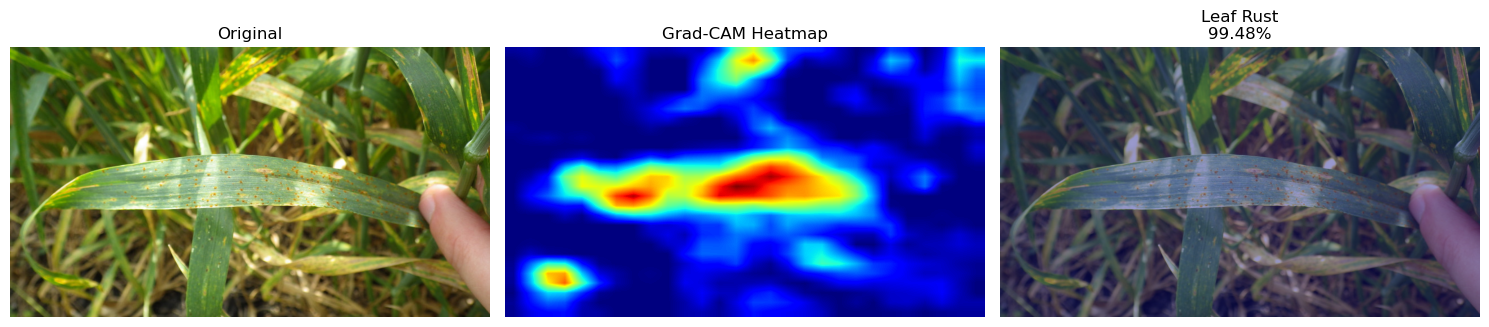

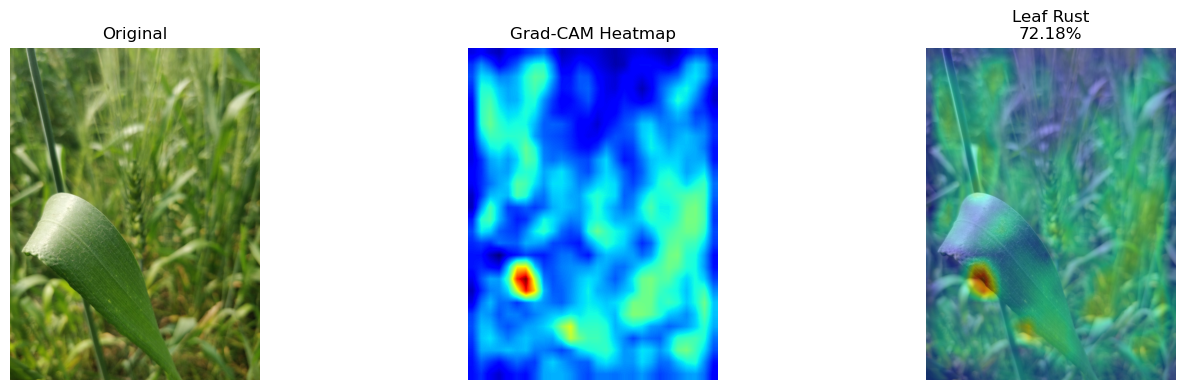

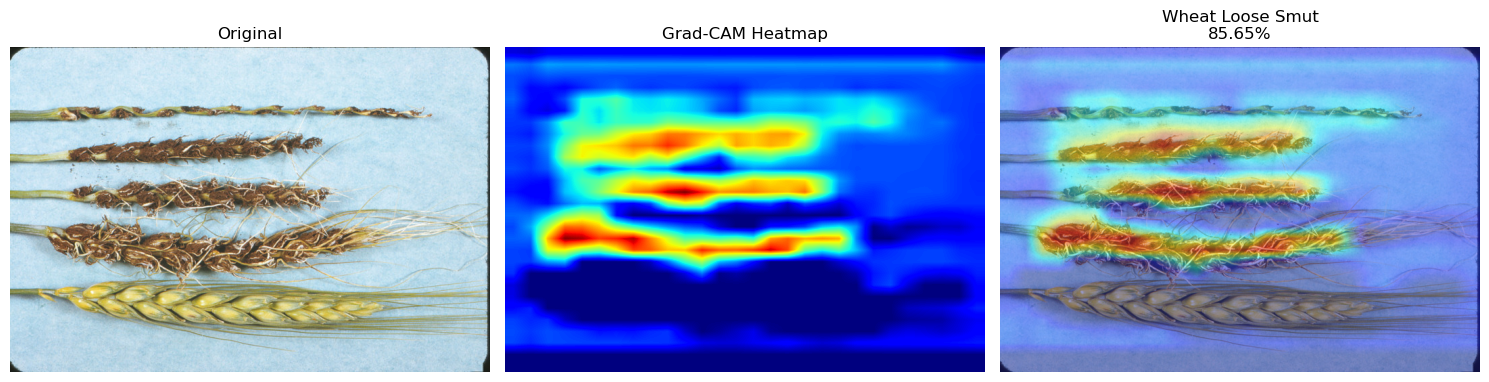

In [6]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.preprocessing import image

# =========================
# PATHS
# =========================
MODEL_PATH = "CustomCNN_final_LWDCD.keras"
CLASS_JSON = "class_names_LWDC.json"

IMAGE_PATHS = [
    r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\leaf rust.jpg",
    r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\Healthy leaf.jpg",
    r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\wheat loose smut.jpg",
]

IMG_SIZE = (224, 224)

# =========================
# LOAD MODEL
# =========================
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

with open(CLASS_JSON, "r", encoding="utf-8") as f:
    class_names = json.load(f)

print("Loaded model.")
print("Layers:")
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

# Force-build model once
_ = model(tf.zeros((1, 255, 255, 3), dtype=tf.float32))

# =========================
# GET LAYERS
# =========================
last_conv_layer = model.get_layer("conv2d_3")
pool_layer = model.get_layer("max_pooling2d_3")
gap_layer = model.get_layer("global_average_pooling2d")
dense_layer = model.get_layer("dense")
dropout_layer = model.get_layer("dropout")
classifier_layer = model.get_layer("dense_1")

# Model up to last conv layer
conv_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=last_conv_layer.output
)

# =========================
# PREPROCESS
# =========================
def load_and_preprocess_image(img_path, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# =========================
# GRAD-CAM FOR CUSTOM CNN
# =========================
def make_gradcam_heatmap(
    img_array,
    conv_model,
    pool_layer,
    gap_layer,
    dense_layer,
    dropout_layer,
    classifier_layer,
    pred_index=None
):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_tensor, training=False)
        tape.watch(conv_outputs)

        x = pool_layer(conv_outputs)
        x = gap_layer(x)
        x = dense_layer(x)
        x = dropout_layer(x, training=False)
        preds = classifier_layer(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_score = preds[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)

    conv_outputs = conv_outputs[0]
    grads = grads[0]

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()
# =========================
# OVERLAY
# =========================
def overlay_heatmap(img_path, heatmap, alpha=0.4):
    original_bgr = cv2.imread(img_path)
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    heatmap_resized = cv2.resize(heatmap, (original_rgb.shape[1], original_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original_rgb, 1 - alpha, heatmap_color, alpha, 0)
    return original_rgb, heatmap_resized, overlay

# =========================
# RUN INFERENCE
# =========================
results = []

for img_path in IMAGE_PATHS:
    print("\n" + "=" * 70)
    print("Image:", img_path)

    img_array = load_and_preprocess_image(img_path)
    preds = model.predict(img_array, verbose=0)[0]

    pred_idx = int(np.argmax(preds))
    pred_class = class_names[pred_idx]
    confidence = float(preds[pred_idx])

    sorted_probs = sorted(zip(class_names, preds), key=lambda x: x[1], reverse=True)

    print("Predicted class:", pred_class)
    print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print("\nTop predictions:")
    for cls, prob in sorted_probs:
        print(f"  {cls:25s} {prob:.4f} ({prob*100:.2f}%)")

    heatmap = make_gradcam_heatmap(
        img_array=img_array,
        conv_model=conv_model,
        pool_layer=pool_layer,
        gap_layer=gap_layer,
        dense_layer=dense_layer,
        dropout_layer=dropout_layer,
        classifier_layer=classifier_layer,
        pred_index=pred_idx
    )

    original_rgb, heatmap_resized, overlay = overlay_heatmap(img_path, heatmap)

    results.append({
        "img_path": img_path,
        "pred_class": pred_class,
        "confidence": confidence,
        "probs": sorted_probs,
        "original": original_rgb,
        "heatmap": heatmap_resized,
        "overlay": overlay
    })

# =========================
# DISPLAY
# =========================
for r in results:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(r["original"])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(r["heatmap"], cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(r["overlay"])
    plt.title(f'{r["pred_class"]}\n{r["confidence"]*100:.2f}%')
    plt.axis("off")

    plt.tight_layout()
    plt.show()